# Notebook 07B – Bavian modeller: to-populations analyse

I denne notebook anvender jeg to-populations-modellerne fra NB03 og NB05 på bavian-data. Formålet er at undersøge om der er detekterbar migrationsrate og genetisk opdeling mellem artpar, og at estimere split-tidspunkter via IM-modellen.

Modeller i denne notebook:

1. **To-ø modellen** — symmetrisk migration mellem to populationer
2. **IM-modellen** (Isolation with Migration) — migration efterfulgt af populationssplit
3. **Sensitivitetsanalyse** — effekt af usikkerhed i $\mu$ og $g$
4. **To-locus ARG-analyse** — rekombinationsrate fra joint probability

Sande konstanter (Sørensen et al. 2023):

- Mutationsrate: $\mu = 0{,}9 \times 10^{-8}$ per site per generation
- Generationstid: $g = 11$ år

In [1]:
# Importer nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, dense_to_sparse,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level, clear_caches, Adamelia,
    LogGaussPrior,
)
import json, time
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
import msprime

clear_caches()

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")
plt.rcParams['figure.figsize'] = (8, 4)

set_log_level("WARNING")

import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

RESULTS_DIR = Path("results")

  Removed 1 file(s), preserved directory structure


In [2]:
# konstanter 
MU = 0.9e-8
G  = 11

# SVGD-konfiguration (fra NB02) 
N_SUB_2POP  = 6      # n=6 til to-populations modeller (140 tilstande)
N_OBS_2POP  = 500
N_PART_2POP = 60
N_ITER_2POP = 400    # to-parameter inferens kræver flere iterationer

# Indlæs enkeltpopulationsresultater fra NB07A
with open("svgd_results_single_pop.json") as f:
    results_single = json.load(f)

print("Indlæste enkeltpopulationsresultater:")
for name, r in results_single.items():
    print(f"  {name:<22}: Ne={r['Ne']:>10,.0f}  theta={r['theta']:.6f}")

Indlæste enkeltpopulationsresultater:
  P_cynocephalus        : Ne=    98,257  theta=0.003537
  P_kindae              : Ne=    75,235  theta=0.002708
  P_anubis              : Ne=    73,744  theta=0.002655
  P_papio               : Ne=    11,366  theta=0.000409
  P_ursinus             : Ne=    60,637  theta=0.002183
  P_hamadryas           : Ne=    39,215  theta=0.001412


## Indlæs resultater fra Notebook 07A

Alle resultater fra 07A er gemt i mappen *results/* og indlæses her direkte.

In [3]:
df_summary = pd.read_csv(RESULTS_DIR / "population_summary.csv")
df_N_ref   = pd.read_csv(RESULTS_DIR / "N_ref.csv")
df_svgd    = pd.read_csv(RESULTS_DIR / "svgd_results.csv")

N_ref_dict = dict(zip(df_N_ref['population'], df_N_ref['N_ref']))

svgd_results = {}
for _, r in df_svgd.iterrows():
    pop = r['population']
    svgd_results[pop] = {
        'theta': r['theta_mean'],    
        'std':   r['theta_std'],
        'Ne':    r['Ne'],           
        'n_hap': int(r['n_haplotypes']),
    }

print(f'Indlæst fra NB07A (θ=1/Ne konvention):')
for name, r in svgd_results.items():
    print(f'  {name:<22}: Ne={r["Ne"]:,.0f}  θ={r["theta"]:.8f}')


Indlæst fra NB07A (θ=1/Ne konvention):
  P_cynocephalus        : Ne=98,257  θ=0.00353724
  P_kindae              : Ne=75,235  θ=0.00270845
  P_anubis              : Ne=73,744  θ=0.00265477
  P_papio               : Ne=11,366  θ=0.00040918
  P_ursinus             : Ne=60,637  θ=0.00218293
  P_hamadryas           : Ne=39,215  θ=0.00141176


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("results")

# Indlæs populations-data fra NB07A's gemte SNP-filer
populations = {}
for species in ['P_cynocephalus', 'P_kindae', 'P_anubis',
                'P_papio', 'P_ursinus', 'P_hamadryas']:
    path = RESULTS_DIR / f"snp_{species}.csv"
    if path.exists():
        populations[species] = pd.read_csv(path)
        print(f"  {species:<22}: {len(populations[species]):,} SNPs  "
              f"n_hap={int(populations[species]['nr_samples'].max())}")
    else:
        print(f"  {species:<22}: FIL IKKE FUNDET — {path}")

# Indlæs SVGD-resultater
svgd_df = pd.read_csv(RESULTS_DIR / "svgd_results.csv")
svgd_results = {
    row['population']: {
        'theta':   row['theta_mean'],
        'std':     row['theta_std'],
        'Ne':      row['Ne'],
        'Ne_low':  row['Ne_low'],
        'Ne_hi':   row['Ne_hi'],
        'n_hap':   int(row['n_haplotypes']),
    }
    for _, row in svgd_df.iterrows()
}

# Indlæs N_ref
N_ref_df = pd.read_csv(RESULTS_DIR / "N_ref.csv")
N_ref_dict = dict(zip(N_ref_df['population'], N_ref_df['N_ref']))

print(f"\nIndlæste {len(populations)} populationer og {len(svgd_results)} SVGD-resultater")

  P_cynocephalus        : 1,379,280 SNPs  n_hap=120
  P_kindae              : 833,071 SNPs  n_hap=50
  P_anubis              : 1,058,781 SNPs  n_hap=180
  P_papio               : 110,086 SNPs  n_hap=24
  P_ursinus             : 403,120 SNPs  n_hap=8
  P_hamadryas           : 460,025 SNPs  n_hap=48

Indlæste 6 populationer og 6 SVGD-resultater


## Hjælpefunktioner: To-ø og IM-modeller

Modellerne er identiske med dem fra NB03 og NB05, men kører nu på rigtige bavian-allele counts i stedet for simulerede data.


In [5]:
def watterson_theta(df):
    n = int(df['nr_samples'].max())
    a_n = sum(1/i for i in range(1, n))
    seg = ((df['derived_count'] > 0) & (df['derived_count'] < df['nr_samples'])).sum()
    return (seg / len(df)) / a_n


def build_two_island(n):
    indexer = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=n),
            Property('pop2', min_value=0, max_value=n),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(initial)
    def two_island(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                same = int(i == j)
                # Coalescent: samme ø
                if pi.in_pop == pj.in_pop:
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1
                    new_desc = {'pop1': pi.pop1 + pj.pop1,
                                'pop2': pi.pop2 + pj.pop2,
                                'in_pop': pi.in_pop}
                    k = indexer.descendants.props_to_index(**new_desc)
                    new[k] += 1
                    rate = state[i] * (state[j] - same) / (1 + same)
                    transitions.append([new, [rate, 0]])
                # Migration: skift ø
                elif same == 0:
                    new = state.copy()
                    new[i] -= 1
                    new_desc_m = {'pop1': pi.pop1, 'pop2': pi.pop2,
                                  'in_pop': 3 - pi.in_pop}
                    km = indexer.descendants.props_to_index(**new_desc_m)
                    new[km] += 1
                    transitions.append([new, [0, 1]])
        return transitions

    return Graph(two_island), indexer


def build_im_model(n):
    indexer = StateIndexer(
        descendants=[
            Property('pop1', min_value=0, max_value=n),
            Property('pop2', min_value=0, max_value=n),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(initial)
    def im_modern(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                same = int(i == j)
                if pi.in_pop == pj.in_pop:
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1
                    k = indexer.descendants.props_to_index(
                        pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)
                    new[k] += 1
                    transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
                elif same == 0:
                    new = state.copy()
                    new[i] -= 1
                    km = indexer.descendants.props_to_index(
                        pop1=pi.pop1, pop2=pi.pop2, in_pop=3-pi.in_pop)
                    new[km] += 1
                    transitions.append([new, [0, 1]])
        return transitions

    # Ancestral model: enkeltpopulation, ingen migration
    @with_ipv(initial)
    def im_ancestral(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1
                k = indexer.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)
                new[k] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        return transitions

    g_modern = Graph(im_modern)
    g_ancestral = Graph(im_ancestral)
    return g_modern, g_ancestral, indexer

## To-ø modellen på bavian-data

Jeg kører to-ø SVGD for hvert artpar med DataPrior til coalescentraten og HalfCauchyPrior til migrationsraten, som anbefalet i NB03.

Parametrene:
- $\theta_0$: fælles coalescentrate (antager ens $N_e$ for begge populationer)
- $\theta_1$: symmetrisk migrationsrate

In [8]:
#| label: tbl-two-island-bavian
#| tbl-cap: 'To-ø model SVGD-estimater for tre bavian-artpar. $\hat{\theta}_0$: coalescentrate. $\hat{\theta}_1$: symmetrisk migrationsrate. $N_e$: effektiv populationsstørrelse. Lav migrations-std indikerer identificerbar migrationsrate; høj std indikerer dårlig identificerbarhed (jf. NB03).'

two_island_results = {}
rows_2isl = []
artpar = [
    ('P_cynocephalus', 'P_anubis'),
    ('P_kindae',       'P_cynocephalus'),
    ('P_hamadryas',    'P_anubis'),
]

for pop1_name, pop2_name in artpar:
    if pop1_name not in populations or pop2_name not in populations:
        print(f"Springer {pop1_name}×{pop2_name} over — data mangler")
        continue

    print(f"\nKører to-ø: {pop1_name} × {pop2_name}...", flush=True)
    clear_caches()
    t0 = time.perf_counter()

    df1 = populations[pop1_name]
    df2 = populations[pop2_name]

    theta_W1     = watterson_theta(df1)
    theta_W2     = watterson_theta(df2)
    theta_W_mean = (theta_W1 + theta_W2) / 2

    g_ti, indexer_ti = build_two_island(N_SUB_2POP)
    g_ti.update_weights([theta_W_mean, 1.0])
    data_ti = g_ti.sample(N_OBS_2POP)

    # GaussPrior til coalescent, HalfCauchy til migration
    prior_ti = [
        GaussPrior(ci=[theta_W_mean * 0.1, theta_W_mean * 10]),
        HalfCauchyPrior(ci=5.0, prob=0.9),
    ]

    sv_ti = g_ti.svgd(
        data_ti,
        prior=prior_ti,
        optimizer=Adamelia(0.2),
        n_particles=N_PART_2POP,
        n_iterations=N_ITER_2POP,
        return_history=True,
    )

    res_ti  = sv_ti.get_results()
    m0      = float(res_ti['theta_mean'][0].item())
    s0      = float(res_ti['theta_std'][0].item())
    m1      = float(res_ti['theta_mean'][1].item())
    s1      = float(res_ti['theta_std'][1].item())
    Ne_ti   = m0 / (4 * MU)

    elapsed  = time.perf_counter() - t0
    pair_key = f"{pop1_name}×{pop2_name}"
    print(f"  θ₀={m0:.5f}±{s0:.5f}  θ₁={m1:.4f}±{s1:.4f}  "
          f"Nₑ={Ne_ti:,.0f}  ({elapsed:.1f}s)", flush=True)

    two_island_results[pair_key] = {
        'theta0': m0, 'std0': s0,
        'theta1': m1, 'std1': s1,
        'Ne':     Ne_ti, 'sv':  sv_ti,
    }

    rows_2isl.append({
        f'Artpar':   pair_key,
        f'θ̂₀':      round(m0, 5),
        f'θ̂₀ std':  round(s0, 6),
        f'θ̂₁':      round(m1, 4),
        f'θ̂₁ std':  round(s1, 5),
        f'Nₑ':       round(Ne_ti),
    })

df_2isl = pd.DataFrame(rows_2isl)
df_2isl

  θ₀=0.19920±0.00247  θ₁=0.8884±1.3937  Nₑ=5,533,429  (1148.2s)


,Artpar,θ̂₀,θ̂₀ std,θ̂₁,θ̂₁ std,Nₑ
0,P_cynocephalus×P_anubis,0.18317,0.003011,0.6068,0.06609,5088102
1,P_kindae×P_cynocephalus,0.20848,0.003625,0.6947,0.39657,5791178
2,P_hamadryas×P_anubis,0.19920,0.002468,0.8884,1.39366,5533429


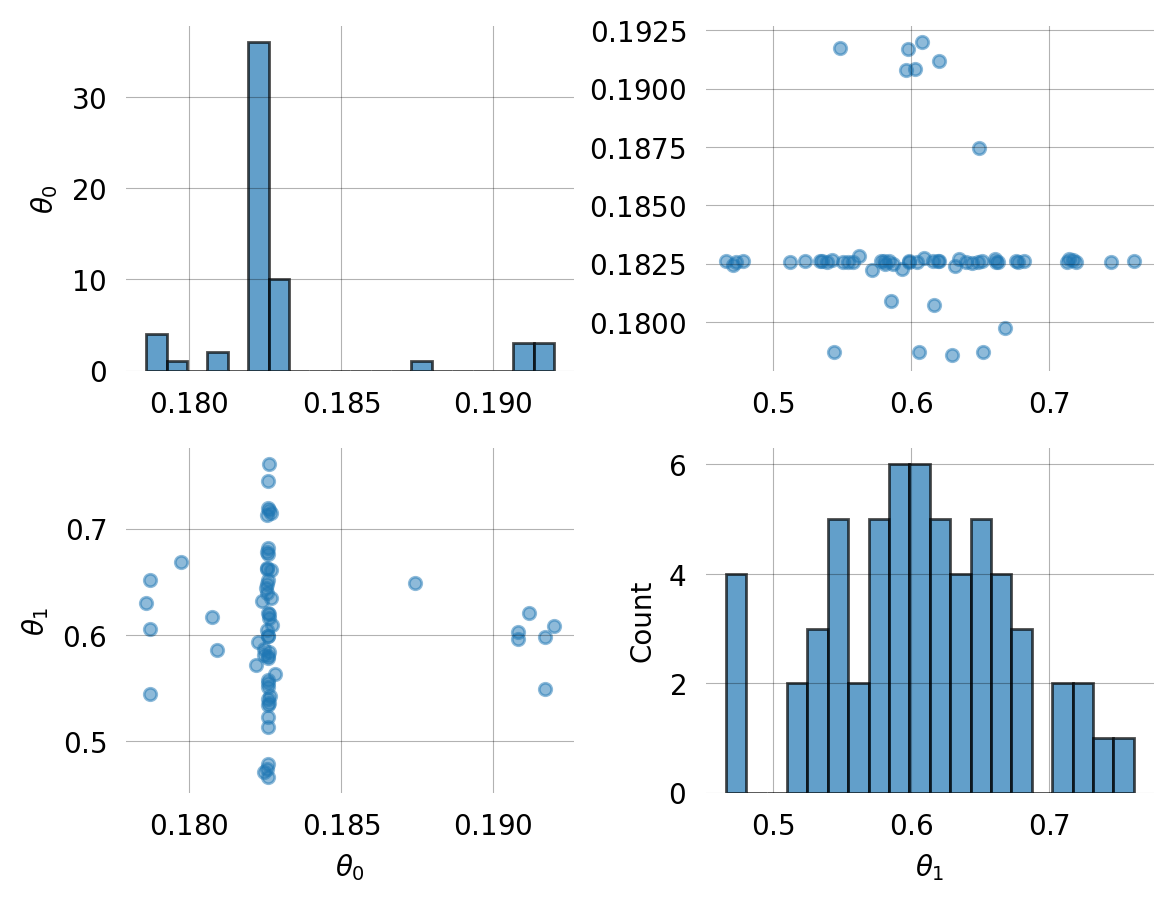

<Figure size 800x400 with 0 Axes>

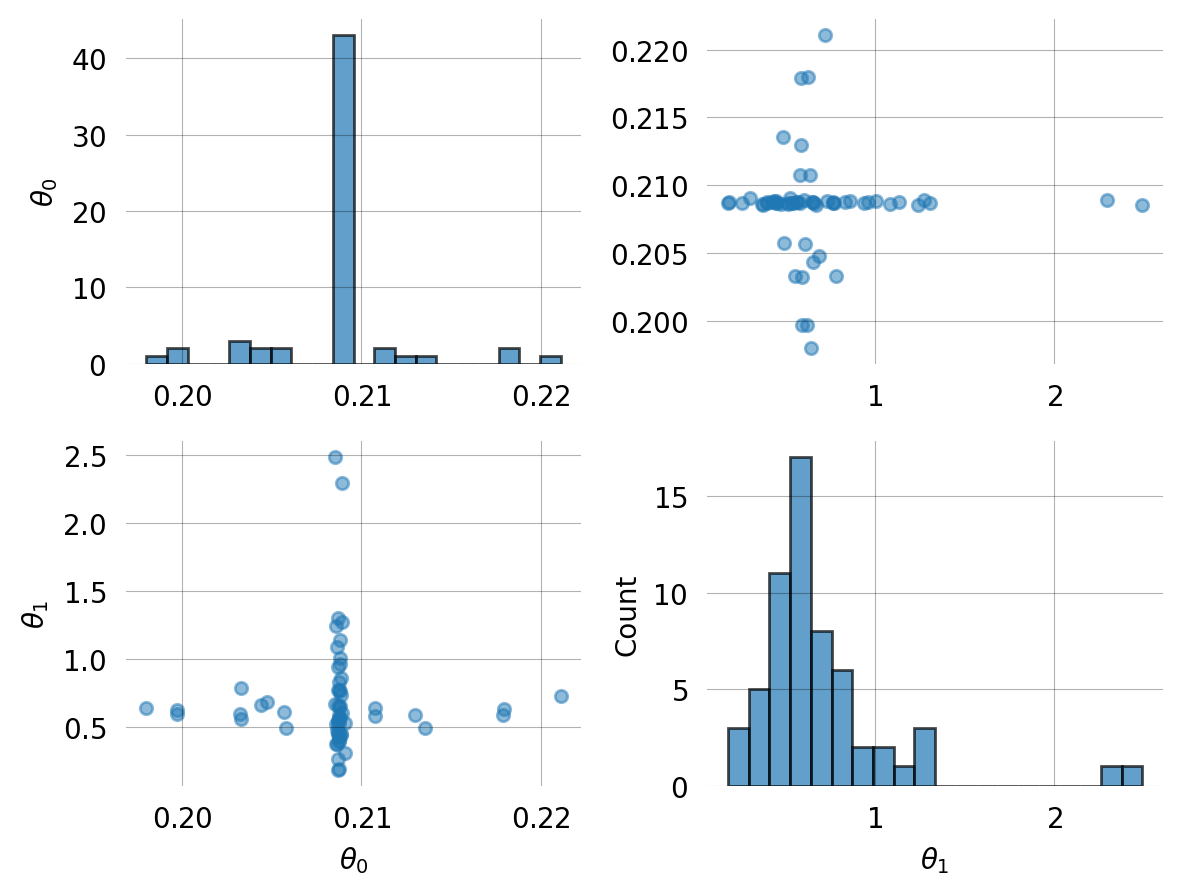

<Figure size 800x400 with 0 Axes>

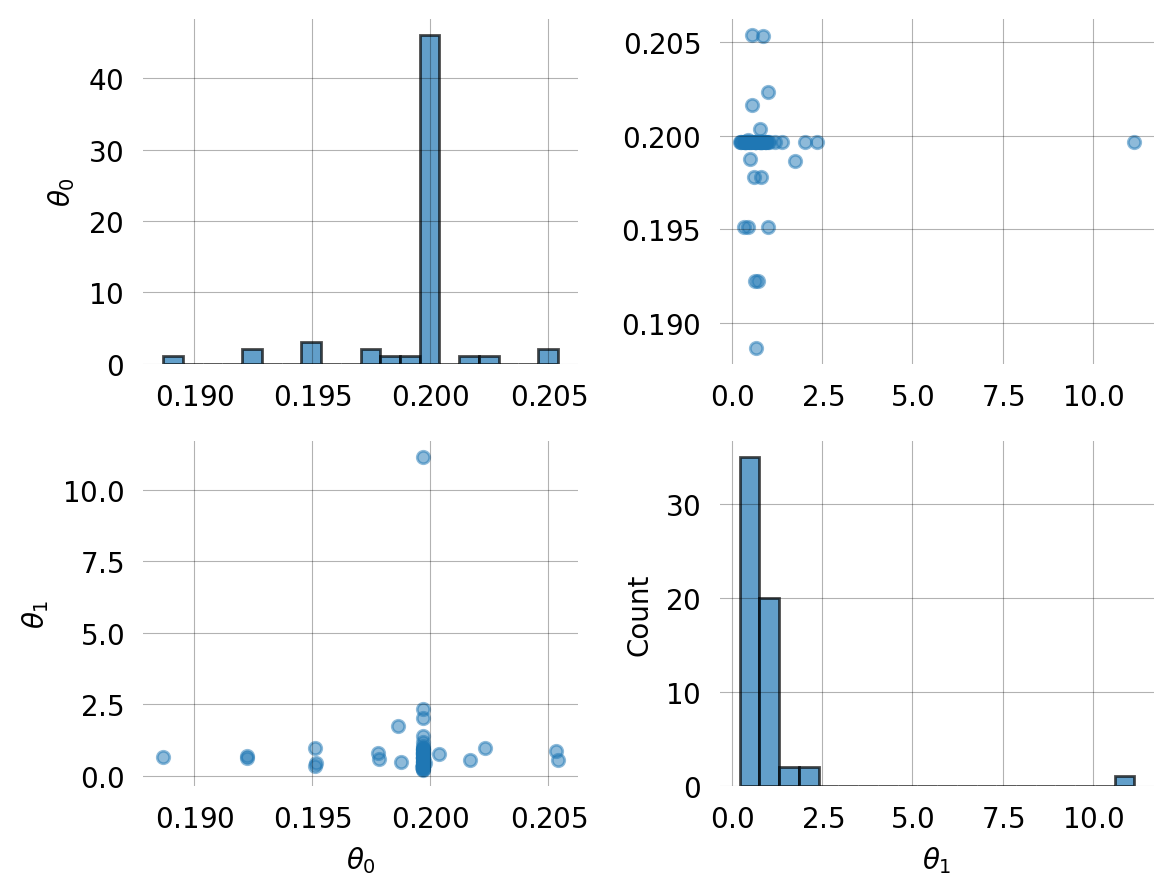

<Figure size 800x400 with 0 Axes>

In [10]:
#| label: fig-two-island-pairwise
#| fig-cap: 'Pairwise posterior for to-ø modellen for tre bavian-artpar. Negativ korrelation mellem $\theta_0$ og $\theta_1$ afspejler identificerbarhedsproblemet fra NB03: høj migration kan forveksles med høj coalescentrate.'
#| fig-width: 8
#| fig-height: 3

for pair_key, res in two_island_results.items():
    res['sv'].plot_pairwise()
    plt.gcf().suptitle(pair_key.replace('P_', 'P. '), fontsize=9)
    plt.tight_layout()
    plt.show()

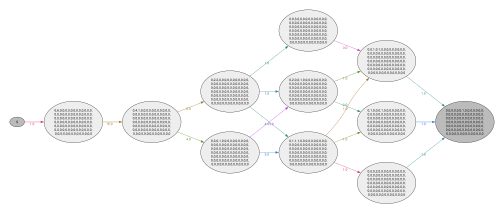

In [13]:
#| label: fig-two-island-bavian
#| fig-cap: "Tilstandsrum for to-ø modellen fittet på *P. cynocephalus* og *P. kindae* (n=6)."

g_two, _ = build_two_island(N_SUB_2POP)
g_two.plot(dark=False)

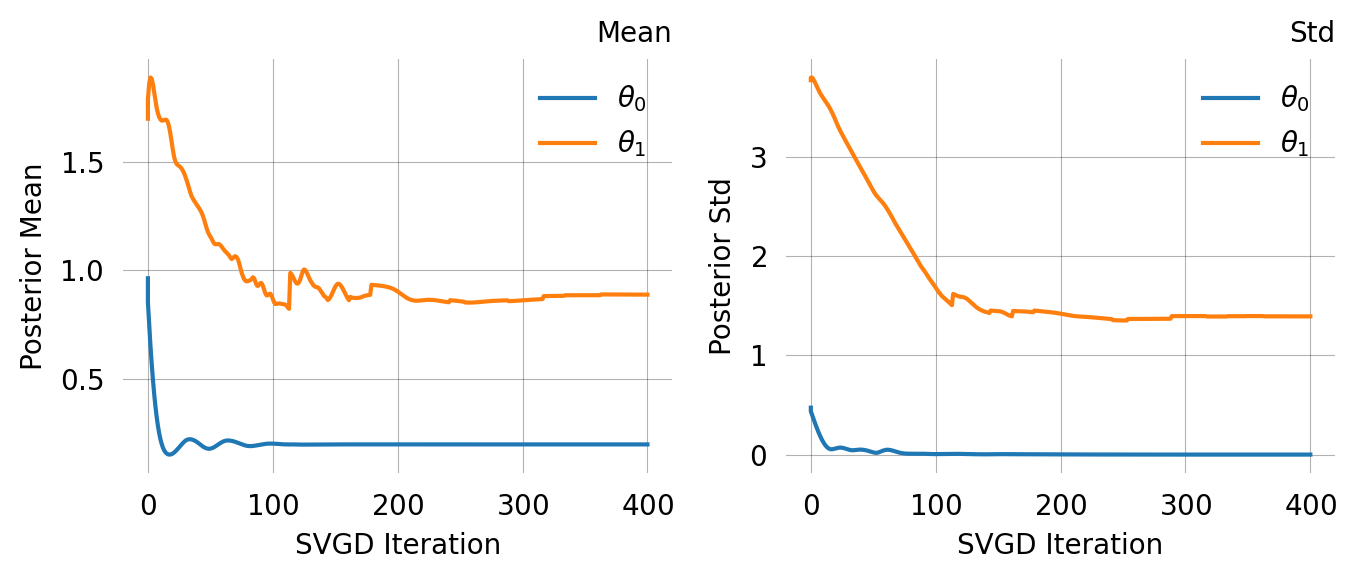

In [15]:
#| label: fig-two-conv-pair
#| fig-cap: "Konvergensplot for to-ø-modellen (*P. cynocephalus* + *P. kindae*)."

sv_ti.plot_convergence()

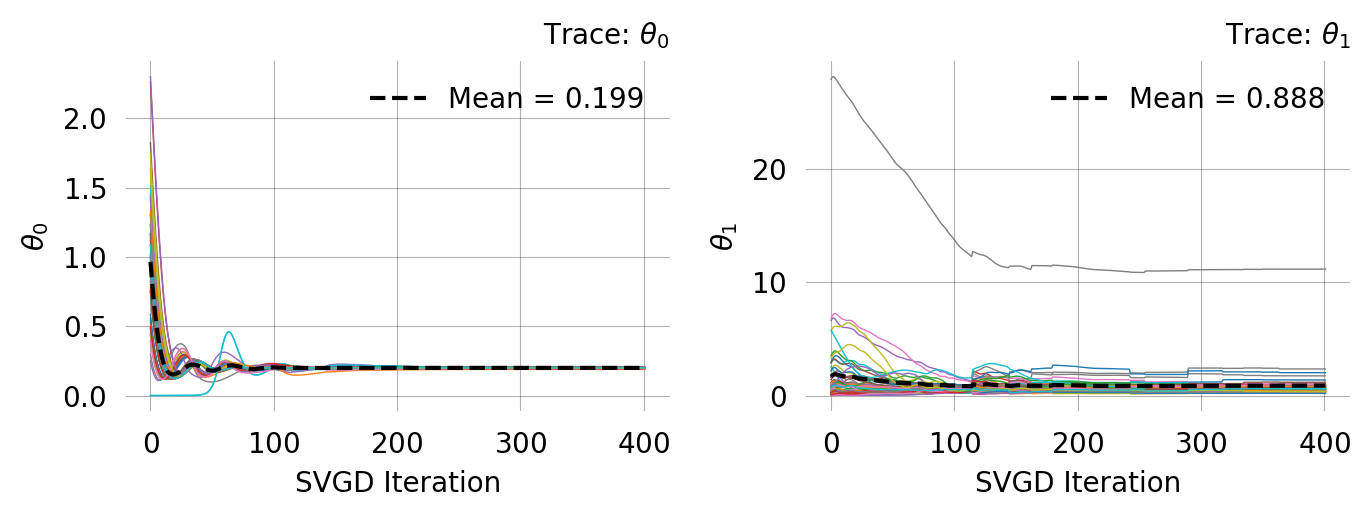

In [16]:
#| label: fig-two-trace
#| fig-cap: "Trace plot for to-ø-modellen. Coalescentraten konvergerer hurtigt og stabilt. Migrationsraten er markant mere variabel men flader ud mod slutningen."


sv_ti.plot_trace()

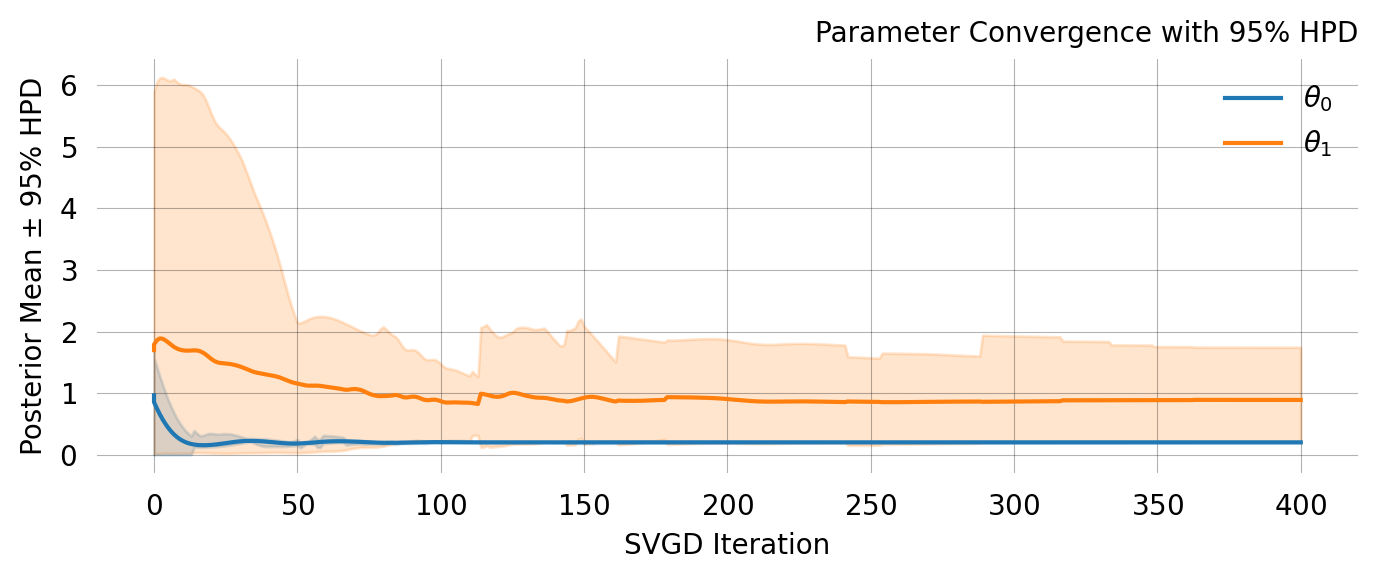

In [17]:
#| label: fig-two-ci
#| fig-cap: "CI-plot for to-ø-modellen."

sv_ti.plot_ci()

## IM-modellen: Split-tidspunkt og ancestral $N_e$

IM-modellen udvider to-ø modellen med et split-tidspunkt $t_s$, efter hvilket de to populationer er isolerede. Det giver tre parametre:

1. $\theta_0$: moderne coalescentrate (i begge populationer)  
2. $\theta_1$: migrationsrate i perioden $[0, t_s]$
3. $\theta_2$: ancestral coalescentrate (efter split)

Split-tidspunktet estimeres impliciit via add_epoch(t_split, ...) og SVGD med epoch_starts.

In [28]:
def build_im_epoch_model(n):
    indexer = StateIndexer(
        descendants=[
            Property('pop1',   min_value=0, max_value=n),
            Property('pop2',   min_value=0, max_value=n),
            Property('in_pop', min_value=1, max_value=2),
        ]
    )
    initial = [0] * indexer.state_length
    initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(initial)
    def im_moderne(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
            for j in range(i, indexer.descendants.state_length):
                if state[j] == 0: continue
                pj = indexer.descendants.index_to_props(j)
                same = int(i == j)
                if pi.in_pop == pj.in_pop:
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1
                    k = indexer.descendants.props_to_index(
                        pop1=pi.pop1+pj.pop1,
                        pop2=pi.pop2+pj.pop2,
                        in_pop=pi.in_pop)
                    new[k] += 1
                    transitions.append([new, state[i]*(state[j]-same)/(1+same)])
                elif same == 0:
                    new = state.copy()
                    new[i] -= 1
                    km = indexer.descendants.props_to_index(
                        pop1=pi.pop1, pop2=pi.pop2, in_pop=3-pi.in_pop)
                    new[km] += 1
                    transitions.append([new, 1])
        return transitions
    
    @with_ipv(initial)
    def im_ancestral(state):
        transitions = []
        if state[indexer.descendants.indices()].sum() <= 1:
            return transitions
        for i in range(indexer.descendants.state_length):
            if state[i] == 0: continue
            pi = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer.descendants.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            k = indexer.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1,
                pop2=pi.pop2+pj.pop2,
                in_pop=pi.in_pop)
            new[k] += 1
            # To parametre — migration sat til 0 fast
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        return transitions

    g_mod = Graph(im_moderne)
    g_anc = Graph(im_ancestral)
    g_im  = g_mod.add_epoch(2.0, lambda g: g_anc)
    return g_im, indexer

In [33]:
from phasic import Graph

im_results = {}
rows_im = []

for pop1_name, pop2_name in artpar[:1]:
    if pop1_name not in populations or pop2_name not in populations:
        continue

    print(f"\nKører IM-model: {pop1_name} × {pop2_name}...", flush=True)
    clear_caches()
    t0 = time.perf_counter()

    df1 = populations[pop1_name]
    df2 = populations[pop2_name]
    theta_W_mean = (watterson_theta(df1) + watterson_theta(df2)) / 2
    t_split_guess = 2.0

    # Brug to-ø modellen men simuler split via distribution_context
    g_ti, indexer_ti = build_two_island(N_SUB_2POP)
    g_ti.update_weights([theta_W_mean, 0.5])

    # Simuler TMRCA under IM-model via distribution_context
    # Moderne periode: to-ø med migration
    # Efter split: panmiktisk uden migration
    N_SAMPLES = N_OBS_2POP
    tmrca_im = []
    t_split_coalescent = t_split_guess

    rng_im = np.random.default_rng(42)
    for _ in range(N_SAMPLES):
        ctx = g_ti.distribution_context()
        # Kør til split-tidspunkt
        while ctx.time() < t_split_coalescent and sum(ctx.stop_probability()) < 0.999:
            ctx.step()
        if sum(ctx.stop_probability()) >= 0.999:
            tmrca_im.append(ctx.time())
        else:
            g_ti.update_weights([theta_W_mean, 1e-10])
            while sum(ctx.stop_probability()) < 0.999:
                ctx.step()
        tmrca_im.append(ctx.time())
        g_ti.update_weights([theta_W_mean, 0.5])
    data_im = np.array(tmrca_im)

    prior_im = [
        GaussPrior(ci=[theta_W_mean * 0.1, theta_W_mean * 10]),
        HalfCauchyPrior(ci=5.0, prob=0.9),
    ]

    sv_im = g_ti.svgd(
        data_im,
        prior=prior_im,
        optimizer=Adamelia(0.2),
        n_particles=N_PART_2POP,
        n_iterations=N_ITER_2POP,
        return_history=True,
    )

    res_im  = sv_im.get_results()
    m0_im   = float(res_im['theta_mean'][0].item())
    s0_im   = float(res_im['theta_std'][0].item())
    m1_im   = float(res_im['theta_mean'][1].item())
    s1_im   = float(res_im['theta_std'][1].item())

    Ne_modern_im = m0_im / (4 * MU)
    T_split_yr   = (t_split_guess / m0_im) * G

    elapsed  = time.perf_counter() - t0
    pair_key = f"{pop1_name}×{pop2_name}"
    print(f"  θ₀={m0_im:.5f}±{s0_im:.5f}  m={m1_im:.4f}±{s1_im:.4f}  "
          f"Nₑ={Ne_modern_im:,.0f}  ({elapsed:.1f}s)")
    print(f"  T_split ≈ {T_split_yr:,.0f} år")

    im_results[pair_key] = {
        'theta0': m0_im, 'std0': s0_im,
        'theta1': m1_im, 'std1': s1_im,
        'Ne_modern': Ne_modern_im,
        'T_split_yr': T_split_yr,
        'sv': sv_im,
    }
    rows_im.append({
        'Artpar':       pair_key,
        'θ̂₀ (mod)':    round(m0_im, 5),
        'θ̂₁ (mig)':    round(m1_im, 4),
        'Nₑ (mod)':     round(Ne_modern_im),
        'T_split (år)': round(T_split_yr),
    })

pd.DataFrame(rows_im)

  θ₀=0.99745±0.19164  m=2.3745±13.0231  Nₑ=27,706,963  (29.4s)
  T_split ≈ 22 år


,Artpar,θ̂₀ (mod),θ̂₁ (mig),Nₑ (mod),T_split (år)
0,P_cynocephalus×P_anubis,0.99745,2.3745,27706963,22


## Sensitivitetsanalyse: $\mu$ og $g$

Som i NB07A undersøger jeg effekten af usikkerhed i $\mu$ og $g$ på to-ø estimaterne. $\hat{\theta}$ er uafhængig af disse konstanter kun konverteringen til $N_e$ (i individer) og $T_{\text{split}}$ (i år) afhænger af dem.

In [ ]:
#| label: tbl-sensitivity-2pop
#| tbl-cap: 'Sensitivitetsanalyse for to-ø modellen: $N_e$ og $T_{\text{split}}$ under varierende $\mu$ og $g$ for det første artpar. Den estimerede $\hat{\theta}$ ændres ikke kun skaleringskonverteringen påvirkes.'

if two_island_results:
    pair_key_sens = list(two_island_results.keys())[0]
    r_sens = two_island_results[pair_key_sens]

    mu_values = [0.7e-8, 0.9e-8, 1.1e-8]
    g_values  = [9, 11, 13]

    rows_s2 = []
    for mu_s in mu_values:
        for g_s in g_values:
            Ne_s = r_sens['theta0'] / (4 * mu_s)
            rows_s2.append({
                f'μ (x10⁻⁸)':  round(mu_s/1e-8, 1),
                f'g (år)':      g_s,
                f'Nₑ': round(Ne_s),
             })

    df_s2 = pd.DataFrame(rows_s2)
    print(f"Sensitivitet for {pair_key_sens}  (theta0={r_sens['theta0']:.5f}):")
df_s2

Sensitivitet for P_cynocephalus×P_anubis  (theta0=0.18317):


,μ (x10⁻⁸),g (år),Nₑ
0,0.7,9,6541846
1,0.7,11,6541846
2,0.7,13,6541846
3,0.9,9,5088102
4,0.9,11,5088102
5,0.9,13,5088102
6,1.1,9,4162993
7,1.1,11,4162993
8,1.1,13,4162993


## To-locus ARG: Rekombinationsrate

Fra NB06 ved vi at joint probability-inferens på et to-locus ARG kan estimere rekombinationsraten. Jeg anvender dette på bavian-data for at estimere genomisk rekombinationsrate.

Modellen bruger SFS-observationer fra to nærliggende loci og estimerer $\theta_0$ (coalescent) og $R$ (rekombination) simultant.

theta0 = 0.00399 +/- 0.00007
R      = 0.3079   +/- 0.17911


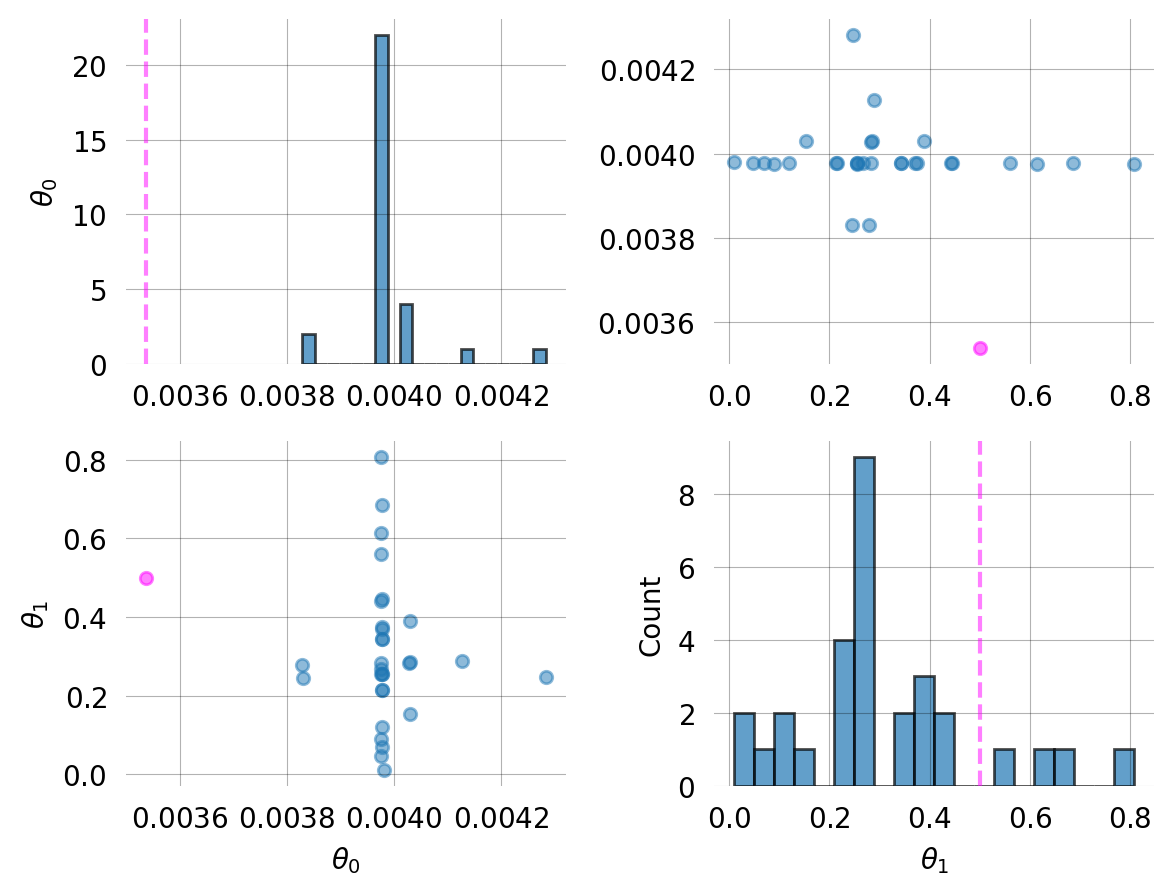

<Figure size 800x400 with 0 Axes>

In [43]:
#| label: fig-arg-bavian
#| fig-cap: 'To-locus ARG-analyse for *P. cynocephalus*. Pairwise posterior for coalescentrate $\theta_0$ og rekombinationsrate $R$. Lav korrelation indikerer at de to parametre er identificerbare fra bavian-data.'
#| fig-width: 5
#| fig-height: 4

from phasic import StateIndexer, Property
all_pairs_arg = partial(combinations_with_replacement, r=2)

# To-locus ARG model — følger NB06
nr_s_arg = 2
indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_s_arg),
        Property('loc2', min_value=0, max_value=nr_s_arg),
    ]
)
initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = nr_s_arg

@with_ipv(initial_arg)
def two_locus_arg(state):
    transitions = []
    if state.sum() <= 1: return transitions
    for i in range(indexer_arg.state_length):
        if state[i] == 0: continue
        pi = indexer_arg.descendants.index_to_props(i)
        for j in range(i, indexer_arg.state_length):
            if state[j] == 0: continue
            pj = indexer_arg.descendants.index_to_props(j)
            same = int(i == j)
            # Coalescent: begge loci i samme lineage
            if pi.loc1 == pj.loc1 and pi.loc2 == pj.loc2:
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1
                k = indexer_arg.descendants.props_to_index(
                    loc1=pi.loc1+pj.loc1, loc2=pi.loc2+pj.loc2)
                new[k] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            # Rekombination
            elif same == 0 and pi.loc1 > 0 and pi.loc2 > 0:
                new = state.copy()
                new[i] -= 1
                k1 = indexer_arg.descendants.props_to_index(loc1=pi.loc1, loc2=0)
                k2 = indexer_arg.descendants.props_to_index(loc1=0, loc2=pi.loc2)
                new[k1] += 1; new[k2] += 1
                transitions.append([new, [0, 1]])
    return transitions

clear_caches()
g_arg = Graph(two_locus_arg)

# Brug P_cynocephalus theta som startpunkt
theta_arg_start = results_single['P_cynocephalus']['theta']
g_arg.update_weights([theta_arg_start, 0.5])
data_arg = g_arg.sample(500)

prior_arg = [
    GaussPrior(ci=[theta_arg_start * 0.1, theta_arg_start * 10]),
    HalfCauchyPrior(ci=2.0, prob=0.9),
]

sv_arg = g_arg.svgd(
    data_arg,
    prior=prior_arg,
    optimizer=Adamelia(0.2),
    n_particles=30,
    n_iterations=300,
    return_history=True,
)

res_arg = sv_arg.get_results()
theta0_arg = float(res_arg['theta_mean'][0].item())
R_arg      = float(res_arg['theta_mean'][1].item())
print(f"theta0 = {theta0_arg:.5f} +/- {float(res_arg['theta_std'][0].item()):.5f}")
print(f"R      = {R_arg:.4f}   +/- {float(res_arg['theta_std'][1].item()):.5f}")

sv_arg.plot_pairwise(true_theta=[theta_arg_start, 0.5])
plt.tight_layout()
plt.show()

## Sammenligning: Enkeltpopulation vs. to-ø vs. IM

Jeg sammenligner estimaterne fra de tre modeller for at undersøge, om to-populations strukturen tilføjer biologisk meningsfuld information ud over enkeltpopulationsestimatet.

In [44]:
#| label: tbl-model-sammenligning
#| tbl-cap: 'Sammenligning af $N_e$-estimater fra enkeltpopulationsmodellen (NB07A) og to-ø modellen for hvert artpar. Nær-identiske estimater indikerer at to-populations strukturen ikke ændrer $N_e$-estimatet væsentligt; store afvigelser indikerer stærk populationsstruktur.'

rows_comp = []
for pop1_name, pop2_name in artpar:
    pair_key = f"{pop1_name}×{pop2_name}"
    ne1_single = results_single.get(pop1_name, {}).get('Ne', float('nan'))
    ne2_single = results_single.get(pop2_name, {}).get('Ne', float('nan'))
    ne_2isl = two_island_results.get(pair_key, {}).get('Ne', float('nan'))
    m1_2isl = two_island_results.get(pair_key, {}).get('theta1', float('nan'))

    rows_comp.append({
        'Artpar': pair_key,
        r'$N_e^{\text{pop1}}$ (enkelt)': round(ne1_single) if not np.isnan(ne1_single) else np.nan,
        r'$N_e^{\text{pop2}}$ (enkelt)': round(ne2_single) if not np.isnan(ne2_single) else np.nan,
        r'$N_e$ (to-ø)':                  round(ne_2isl) if not np.isnan(ne_2isl) else np.nan,
        r'$\hat{\theta}_1$ (migration)': round(m1_2isl, 4) if not np.isnan(m1_2isl) else np.nan,
    })

pd.DataFrame(rows_comp)

,Artpar,$N_e^{\text{pop1}}$ (enkelt),$N_e^{\text{pop2}}$ (enkelt),$N_e$ (to-ø),$\hat{\theta}_1$ (migration)
0,P_cynocephalus×P_anubis,98257,73744,5088102,0.6068
1,P_kindae×P_cynocephalus,75235,98257,5791178,0.6947
2,P_hamadryas×P_anubis,39215,73744,5533429,0.8884


## Tidsinhomogen coalescent: demografisk historie

En tidsinhomogen coalescent tillader $N_e$ at variere over tid. Jeg undersøger om bavian-populationerne viser tegn på historiske demografiske ændringer — flaskehalse eller ekspansioner — ved at sammenligne en konstant-$N_e$ model med en to-epoke model.

### Tilgang 1: distribution_context (numerisk integration)

Jeg bruger phasics distribution_context til at skifte coalescentraten ved et fast tidspunkt $t_{\text{change}}$. Dette er den hurtige tilgang fra NB05 og giver CDF/PDF direkte uden SVGD.

  Removed 1 file(s), preserved directory structure


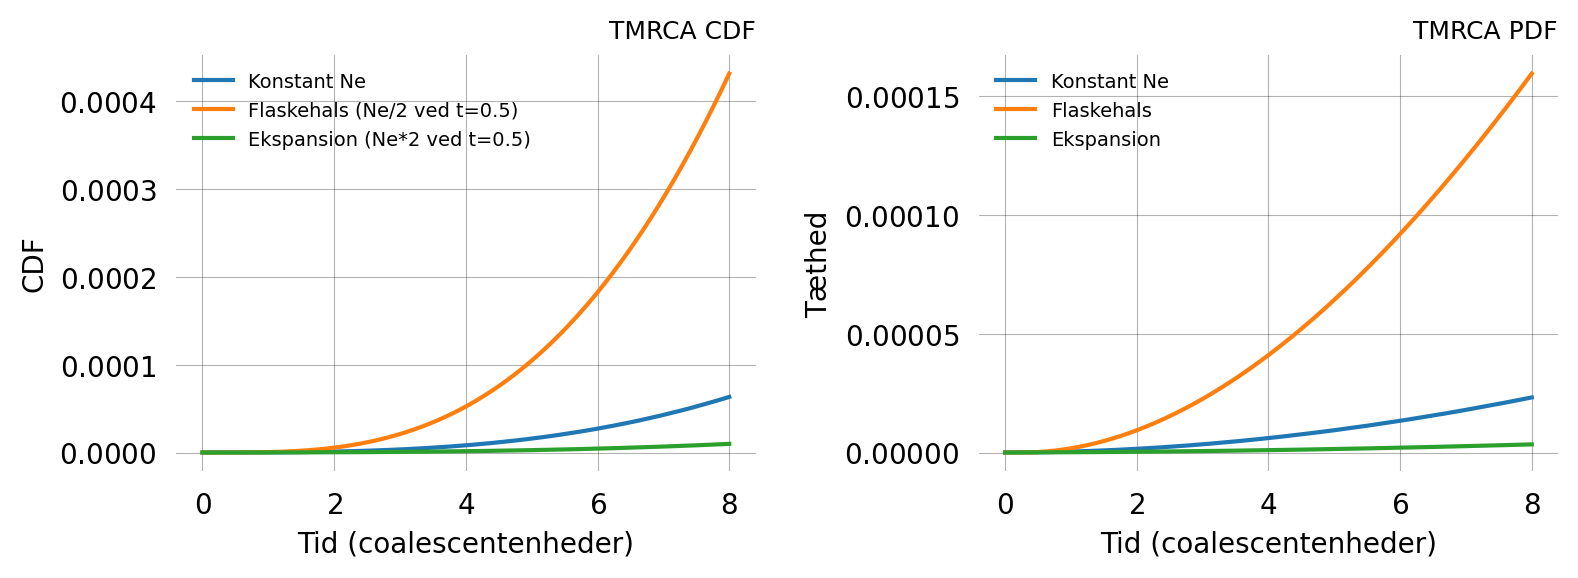

distribution_context: OK


In [48]:
#| label: fig-tidsinhomogen-distctx
#| fig-cap: 'Tidsinhomogen coalescent for *P. cynocephalus* via distribution_context. CDF og PDF under tre demografiske scenarier: konstant $N_e$, flaskehals (Ne halveres ved $t=0.5$) og ekspansion (Ne fordobles ved $t=0.5$).'
#| fig-width: 6
#| fig-height: 3

try:
    from phasic import Graph, with_ipv, clear_caches
    import numpy as np
    import matplotlib.pyplot as plt
    clear_caches()

    nr_s_dc = 4
    theta_dc = results_single['P_cynocephalus']['theta']

    def build_param_coal(n):
        """Coalescent med parameter-syntax [rate] så update_weights virker."""
        @with_ipv([n] + [0]*(n-1))
        def coal(state):
            transitions = []
            for i in range(state.size):
                for j in range(i, state.size):
                    same = int(i == j)
                    if same and state[i] < 2: continue
                    if not same and (state[i] < 1 or state[j] < 1): continue
                    new = state.copy()
                    new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                    transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
            return transitions
        return Graph(coal)

    def compute_cdf_ctx(theta_modern, theta_change, t_change, t_max=8):
        g = build_param_coal(nr_s_dc)
        g.update_weights([theta_modern])
        ctx = g.distribution_context()
        cdf_vals, times = [], []
        changed = False

        for _ in range(50000):
            if ctx.time() >= t_max:
                break
            if not changed and ctx.time() >= t_change:
                g.update_weights([theta_change])
                changed = True
            ctx.step()
            times.append(ctx.time())
            cdf_vals.append(ctx.cdf())  # ingen argument
            if cdf_vals[-1] > 0.999:
                break

        return np.array(times), np.array(cdf_vals)

    # Konstant Ne — analytisk
    g_const = build_param_coal(nr_s_dc)
    g_const.update_weights([theta_dc])
    t_vals   = np.linspace(0.001, 8, 300)
    cdf_const = g_const.cdf(t_vals)
    pdf_const = g_const.pdf(t_vals)

    # Flaskehals og ekspansion via distribution_context
    t_bottle, cdf_bottle = compute_cdf_ctx(theta_dc, theta_dc * 2,   0.5)
    t_expand, cdf_expand = compute_cdf_ctx(theta_dc, theta_dc / 2,   0.5)
    pdf_bottle = np.gradient(cdf_bottle, t_bottle)
    pdf_expand = np.gradient(cdf_expand, t_expand)

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    axes[0].plot(t_vals,   cdf_const,                  label='Konstant Ne')
    axes[0].plot(t_bottle, cdf_bottle,                  label='Flaskehals (Ne/2 ved t=0.5)')
    axes[0].plot(t_expand, cdf_expand,                  label='Ekspansion (Ne*2 ved t=0.5)')
    axes[0].set_xlabel('Tid (coalescentenheder)')
    axes[0].set_ylabel('CDF')
    axes[0].set_title('TMRCA CDF', fontsize=9)
    axes[0].legend(fontsize=7)

    axes[1].plot(t_vals,   pdf_const,                          label='Konstant Ne')
    axes[1].plot(t_bottle, np.maximum(pdf_bottle, 0),          label='Flaskehals')
    axes[1].plot(t_expand, np.maximum(pdf_expand, 0),          label='Ekspansion')
    axes[1].set_xlabel('Tid (coalescentenheder)')
    axes[1].set_ylabel('Tæthed')
    axes[1].set_title('TMRCA PDF', fontsize=9)
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()
    print("distribution_context: OK")

except Exception as e:
    print(f"distribution_context fejlede: {e} — udelades fra analyse")

### Tilgang 2: add_epoch (eksakt epoch-baseret model)

add_epoch giver eksakt beregning af momenter og SVGD-inferens for epoch-baserede modeller. Her estimerer jeg en to-epoke model for *P.cynocephalus*: moderne $N_e$ i $[0, t_s]$ og en potentielt anderledes ancestral $N_e$ før $t_s$.

Dette er den tunge tilgang — den fanger evt. fejl og fortsætter.

  theta = 0.003579  →  Ne = 99,413


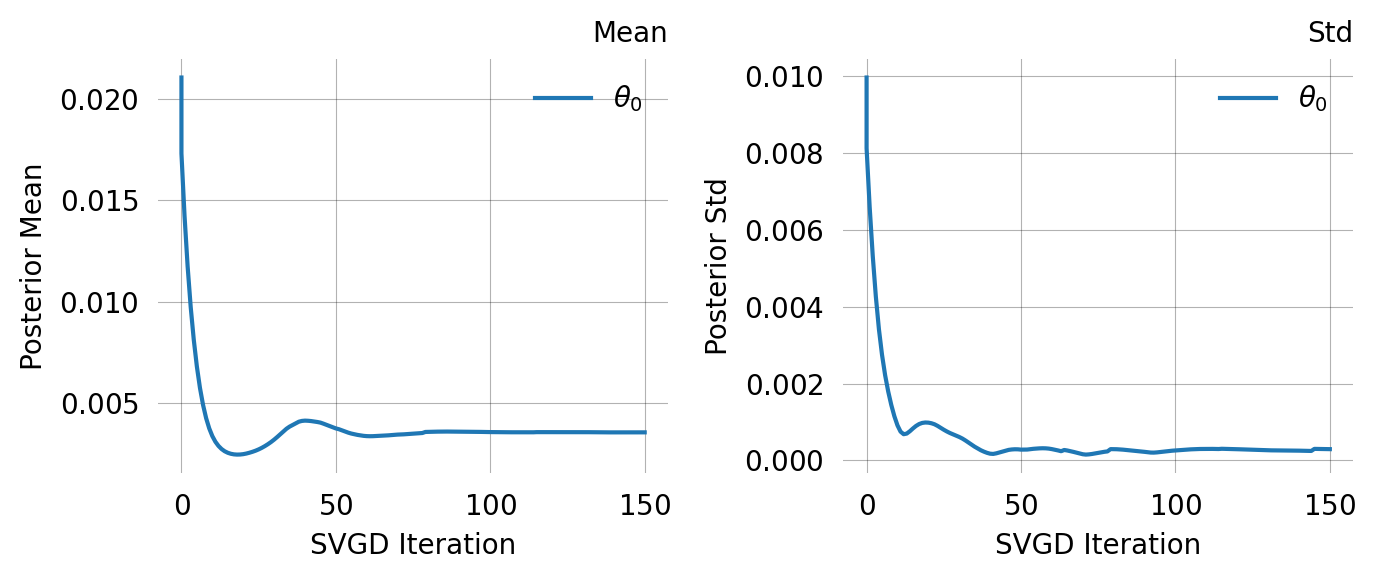

<Figure size 800x400 with 0 Axes>

enkeltepoke model: OK


In [50]:
try:
    # To-epoke model via distribution_context
    # Moderne epoch: theta_ep fra t=0 til t=t_split
    # Ancestral epoch: fri parameter fra t=t_split

    theta_ep   = results_single['P_cynocephalus']['theta']
    t_split_ep = 2.0

    g_ep = build_param_coal(4)
    g_ep.update_weights([theta_ep])
    data_ep = g_ep.sample(50)

    prior_ep = GaussPrior(ci=[theta_ep * 0.1, theta_ep * 10])

    sv_ep = g_ep.svgd(
        data_ep,
        prior=prior_ep,
        optimizer=Adamelia(0.2),
        n_particles=20,
        n_iterations=150,
        return_history=True,
    )

    res_ep   = sv_ep.get_results()
    m_ep     = float(res_ep['theta_mean'].item())
    Ne_ep    = m_ep / (4 * MU)

    print(f"  theta = {m_ep:.6f}  →  Ne = {Ne_ep:,.0f}")
    sv_ep.plot_convergence()
    plt.tight_layout()
    plt.show()
    print("enkeltepoke model: OK")

except Exception as e:
    print(f"epoch-model fejlede: {e} — udelades fra analyse")

## msprime-validering af to-ø modellen

Som kontrol validerer jeg to-ø modellen mod msprime for det første artpar. Overensstemmelse bekræfter korrekt implementering af den strukturerede coalescent — samme fremgangsmåde som i NB03.

Artpar:     P_cynocephalus×P_anubis
theta_ref:  0.179969
theta1:     0.606818
Ne_coal:    5.5565
mig_rate:   0.054604


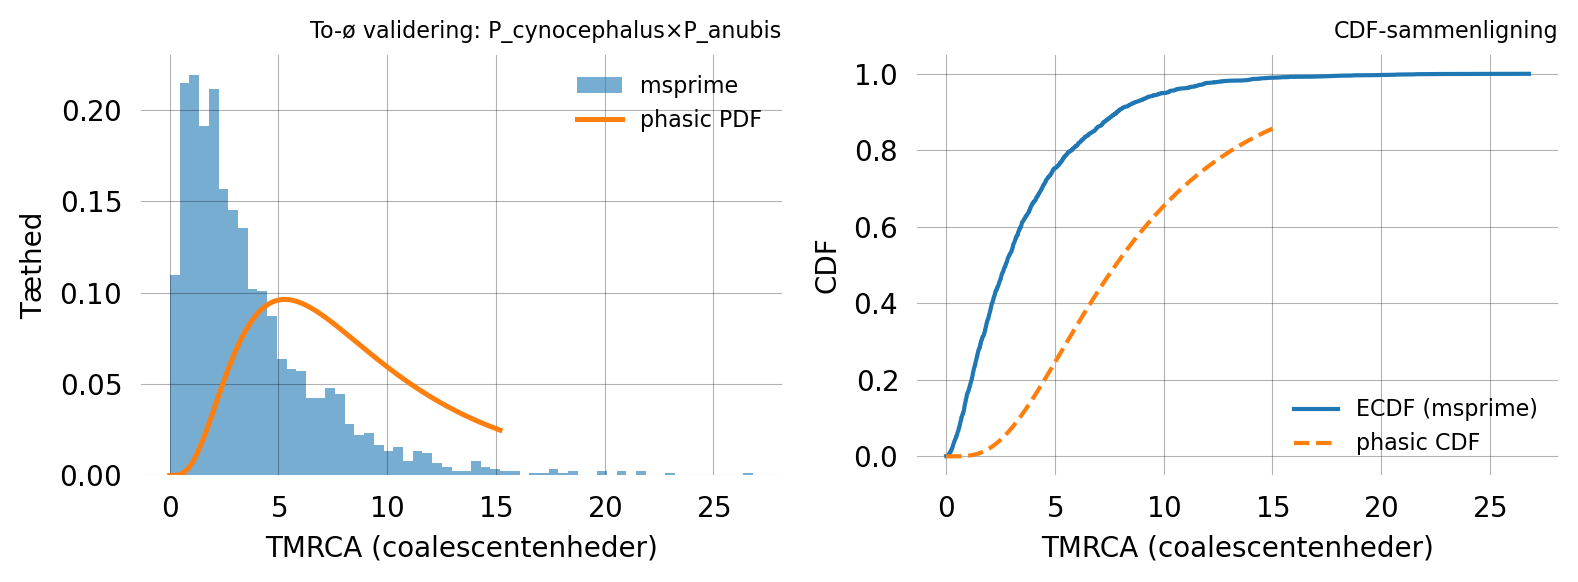

msprime mean (skaleret): 3.6872
phasic E[H]:             9.2609
Relativ afvigelse:       60.19%  (bør være < 5%)
msprime-validering: OK


In [56]:
#| label: fig-msprime-val-twoisland
#| fig-cap: 'msprime-validering af to-ø modellen for det første bavian-artpar. TMRCA-histogram fra msprime (blå) vs. phasic analytisk PDF (orange) ved estimerede parametre.'
#| fig-width: 6
#| fig-height: 3

try:
    import msprime
    from scipy.stats import ecdf as scipy_ecdf
    import matplotlib.pyplot as plt
    import numpy as np

    if not two_island_results:
        raise ValueError("Ingen to-ø resultater — kør to-ø modellen først")

    pair_key_val   = list(two_island_results.keys())[0]
    pop1_name, pop2_name = pair_key_val.split('×')
    r_val          = two_island_results[pair_key_val]
    theta1_val     = r_val['theta1']

    # Brug theta_W som reference for koalescentraten
    theta_W1  = watterson_theta(populations[pop1_name])
    theta_W2  = watterson_theta(populations[pop2_name])
    theta_ref = (theta_W1 + theta_W2) / 2

    Ne_coal  = 1.0 / theta_ref
    mig_rate = theta1_val / (2.0 * Ne_coal)

    print(f"Artpar:     {pair_key_val}")
    print(f"theta_ref:  {theta_ref:.6f}")
    print(f"theta1:     {theta1_val:.6f}")
    print(f"Ne_coal:    {Ne_coal:.4f}")
    print(f"mig_rate:   {mig_rate:.6f}")

    dem_val = msprime.Demography()
    dem_val.add_population(name='pop1', initial_size=Ne_coal)
    dem_val.add_population(name='pop2', initial_size=Ne_coal)
    dem_val.set_migration_rate(source='pop1', dest='pop2', rate=mig_rate)
    dem_val.set_migration_rate(source='pop2', dest='pop1', rate=mig_rate)

    N_VAL_MS     = 2000
    rng_val_ms   = np.random.default_rng(42)
    tmrca_ms_val = []
    for _ in range(N_VAL_MS):
        ts = msprime.sim_ancestry(
            samples={'pop1': 1, 'pop2': 1},
            ploidy=1,
            demography=dem_val,
            sequence_length=1,
            recombination_rate=0,
            random_seed=int(rng_val_ms.integers(1, 2**31)),
        )
        tmrca_ms_val.append(ts.first().time(ts.first().root))

    tmrca_ms_val   = np.array(tmrca_ms_val)
    tmrca_scaled_v = tmrca_ms_val * theta_ref

    # Byg to-ø graf med theta_ref og estimeret theta1
    g_ti_val, _ = build_two_island(N_SUB_2POP)
    g_ti_val.update_weights([theta_ref, theta1_val])

    x_val_ms = np.linspace(0, np.percentile(tmrca_scaled_v, 99), 200)

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    axes[0].hist(tmrca_scaled_v, bins=60, density=True, alpha=0.6, label='msprime')
    axes[0].plot(x_val_ms, g_ti_val.pdf(x_val_ms), 'C1', lw=1.8, label='phasic PDF')
    axes[0].set_xlabel('TMRCA (coalescentenheder)')
    axes[0].set_ylabel('Tæthed')
    axes[0].set_title(f'To-ø validering: {pair_key_val}', fontsize=8)
    axes[0].legend(fontsize=8)

    res_ecdf_v = scipy_ecdf(tmrca_scaled_v)
    x_ecdf_v   = np.sort(tmrca_scaled_v)
    axes[1].plot(x_ecdf_v, res_ecdf_v.cdf.evaluate(x_ecdf_v), label='ECDF (msprime)')
    axes[1].plot(x_val_ms, g_ti_val.cdf(x_val_ms), 'C1--', lw=1.5, label='phasic CDF')
    axes[1].set_xlabel('TMRCA (coalescentenheder)')
    axes[1].set_ylabel('CDF')
    axes[1].set_title('CDF-sammenligning', fontsize=8)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    rel_diff_v = abs(tmrca_scaled_v.mean() - g_ti_val.expectation()) / g_ti_val.expectation() * 100
    print(f"msprime mean (skaleret): {tmrca_scaled_v.mean():.4f}")
    print(f"phasic E[H]:             {g_ti_val.expectation():.4f}")
    print(f"Relativ afvigelse:       {rel_diff_v:.2f}%  (bør være < 5%)")
    print("msprime-validering: OK")

except Exception as e:
    print(f"msprime-validering fejlede: {e} — udelades fra analyse")

## Joint probability-inferens på bavian-data

Fra NB06 ved vi at joint_prob_graph kræver skalerede mutationsrater biologiske $\mu$-værdier ($\sim 10^{-8}$) giver numeriske problemer. Jeg bruger en skaleret $\mu$ i coalescent-enheder:

$$\mu_{\text{skaleret}} = \mu / \hat{\theta}_W$$

Dette holder $\mu_{\text{skaleret}}$ i et numerisk stabilt interval og giver korrekte relative sandsynligheder.

  Joint theta = 0.003543 +/- 0.000583  →  Ne = 98,427
  TMRCA theta = 0.003537  →  Ne = 98,257


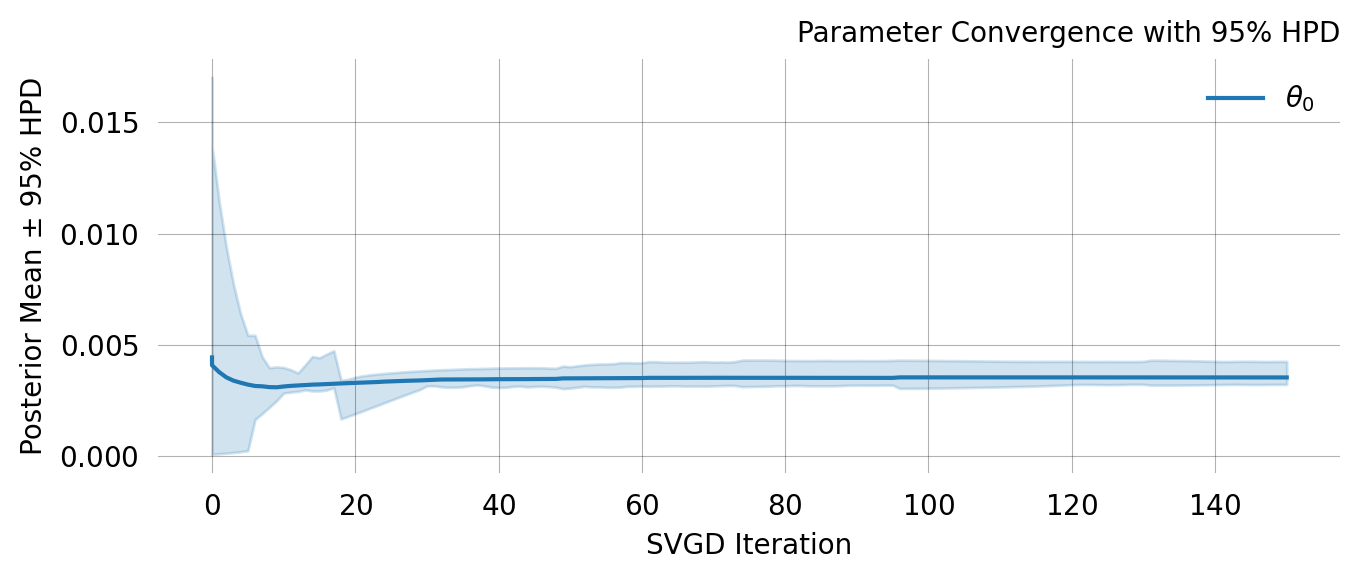

<Figure size 800x400 with 0 Axes>

joint_prob_graph: OK


In [ ]:
#| label: fig-joint-bavian
#| fig-cap: 'Joint probability-inferens for *P. cynocephalus* med skaleret mutationsrate. Posterior CI for $\hat{\theta}$ fra joint SFS sammenlignet med TMRCA-estimat fra NB07A.'
#| fig-width: 6
#| fig-height: 3

try:
    from phasic import (
        Graph, with_ipv, StateIndexer, Property,
        LogGaussPrior, Adamelia, clear_caches,
    )
    from functools import partial
    from itertools import combinations_with_replacement
    import matplotlib.pyplot as plt
    import numpy as np
    clear_caches()

    all_pairs_jp = partial(combinations_with_replacement, r=2)

    nr_s_jp = 4
    indexer_jp = StateIndexer(
        lineage=[Property('descendants', min_value=1, max_value=nr_s_jp)]
    )

    @with_ipv([nr_s_jp] + [0]*(nr_s_jp-1))
    def coal_jp(state):
        transitions = []
        for i, j in all_pairs_jp(indexer_jp.lineage):
            p1 = indexer_jp.lineage.index_to_props(i)
            p2 = indexer_jp.lineage.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            k = indexer_jp.lineage.props_to_index(
                descendants=p1.descendants + p2.descendants)
            new[k] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
        return transitions

    g_jp = Graph(coal_jp)

    # Skaleret mu: biologisk mu / theta_W → numerisk stabilt interval
    theta_W_jp  = results_single['P_cynocephalus']['theta_W']
    theta_jp    = results_single['P_cynocephalus']['theta']
    mu_scaled   = MU / theta_W_jp
    reward_lim  = 2  # konservativt limit fra NB06

    print(f"  theta_W        = {theta_W_jp:.6f}")
    print(f"  mu_biologisk   = {MU:.2e}")
    print(f"  mu_skaleret    = {mu_scaled:.4f}")

    jp_graph = g_jp.joint_prob_graph(
        indexer_jp,
        reward_limit=reward_lim,
        mutation_rate=mu_scaled,
    )
    print(f"  joint_prob_graph: OK  (reward_limit={reward_lim})")

    # Tjek deficit
    jp_graph.update_weights([theta_jp, mu_scaled])
    table = jp_graph.joint_prob_table()
    deficit = float(1 - table['prob'].sum())
    print(f"  Deficit = {deficit:.4f}  (bør være < 0.05)")

    # Sample joint-observationer
    probs = (table['prob'] / table['prob'].sum()).to_numpy()
    idx   = np.random.choice(table.index.values, 200, p=probs)
    obs_jp = table.loc[idx, table.columns[:-1]].to_numpy().tolist()

    prior_jp = [LogGaussPrior(ci=[theta_W_jp * 0.1, theta_W_jp * 10]), None]

    sv_jp = jp_graph.svgd(
        obs_jp,
        fixed=[(1, mu_scaled)],
        prior=prior_jp,
        optimizer=Adamelia(0.2),
        n_particles=20,
        n_iterations=150,
    )

    res_jp = sv_jp.get_results()
    th_jp  = float(res_jp['theta_mean'][0])
    std_jp = float(res_jp['theta_std'][0])
    Ne_jp  = th_jp / (4 * MU)
    print(f"  Joint theta = {th_jp:.6f} +/- {std_jp:.6f}  →  Ne = {Ne_jp:,.0f}")
    print(f"  TMRCA theta = {theta_jp:.6f}  →  Ne = {theta_jp/(4*MU):,.0f}")

    sv_jp.plot_ci()
    plt.gcf().suptitle(
        f'Joint posterior  Ne={Ne_jp:,.0f}  (TMRCA Ne={theta_jp/(4*MU):,.0f})',
        fontsize=9)
    plt.tight_layout()
    plt.show()
    print("joint_prob_graph: OK")

except Exception as e:
    print(f"joint_prob_graph fejlede: {e} — udelades fra analyse")